In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
df = pd.read_csv("/Users/sarthakkastiya/Desktop/Indo Thai/NIFTY_INTRADAY_2026.csv")

In [62]:
# Convert the date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Make the date column the index
df = df.set_index("date")

df.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 1017763 entries, 2015-01-09 09:15:00 to 2026-01-09 14:21:00
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   open    1017763 non-null  float64
 1   high    1017763 non-null  float64
 2   low     1017763 non-null  float64
 3   close   1017763 non-null  float64
 4   volume  1017763 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 46.6 MB


In [63]:
df = df.sort_index()

In [64]:
WINDOW_SIZE = 1875


In [65]:
#Empty Lists for input and output
X = []
Y = []

In [66]:
for start in range(0, len(df) - (2 * WINDOW_SIZE) + 1, WINDOW_SIZE):

    input_window = df.iloc[start : start + WINDOW_SIZE]

    target_window = df.iloc[start + WINDOW_SIZE : start + (2 * WINDOW_SIZE)]

    input_window = input_window[["close"]].to_numpy()

    target_window = target_window[["close"]].to_numpy()

    X.append(input_window)

    Y.append(target_window)

In [67]:
X = np.array(X)
Y = np.array(Y)

In [68]:
#Spliting the data

split_index = int(len(X) * 0.80)

X_train = X[:split_index]
Y_train = Y[:split_index]

X_test = X[split_index:]
Y_test = Y[split_index:]

In [69]:
print("Total samples :", len(X))

print("Training samples :", len(X_train))

print("Testing samples :", len(X_test))

Total samples : 541
Training samples : 432
Testing samples : 109


In [70]:
#Flattening

X_train_flat = X_train.reshape(X_train.shape[0], -1)

Y_train_flat = Y_train.reshape(Y_train.shape[0], -1)

X_test_flat = X_test.reshape(X_test.shape[0], -1)

Y_test_flat = Y_test.reshape(Y_test.shape[0], -1)

In [71]:
# Compute statistics using only the training data
X_mean = X_train_flat.mean(axis=0)
X_std = X_train_flat.std(axis=0)

Y_mean = Y_train_flat.mean(axis=0)
Y_std = Y_train_flat.std(axis=0)

# Avoid division by zero
X_std[X_std == 0] = 1
Y_std[Y_std == 0] = 1

# Normalize
X_train_flat = (X_train_flat - X_mean) / X_std
X_test_flat = (X_test_flat - X_mean) / X_std

Y_train_flat = (Y_train_flat - Y_mean) / Y_std
Y_test_flat = (Y_test_flat - Y_mean) / Y_std

In [72]:
# Number of training samples
n_samples = X_train_flat.shape[0]

# Number of input features
n_features = X_train_flat.shape[1]

# Number of output features
n_outputs = Y_train_flat.shape[1]

# Hyperparameters
learning_rate = 1e-5
epochs = 100

# Initialize weights and bias
W = np.zeros((n_features, n_outputs))
b = np.zeros((1, n_outputs))


In [73]:
loss_history = []

In [74]:
for epoch in range(epochs):

    # Forward Pass
    Y_pred = X_train_flat @ W + b

    # Loss
    loss = np.mean((Y_train_flat - Y_pred) ** 2)
    loss_history.append(loss)

    # Error
    error = Y_pred - Y_train_flat

    # Gradients
    dW = (2 / n_samples) * (X_train_flat.T @ error)

    db = (2 / n_samples) * np.sum(
        error,
        axis=0,
        keepdims=True
    )

    # Update Parameters
    W = W - learning_rate * dW
    b = b - learning_rate * db

    # Print Loss
    if epoch % 10 == 0:
        print(f"Epoch {epoch}")
        print("Loss:", loss)
        print("||dW||:", np.linalg.norm(dW))
    
    

Epoch 0
Loss: 1.0
||dW||: 3739.0282467493216
Epoch 10
Loss: 0.46856683290433965
||dW||: 2552.2454587067155
Epoch 20
Loss: 0.2209522701716088
||dW||: 1742.1531579498123
Epoch 30
Loss: 0.10557924806344164
||dW||: 1189.188367637155
Epoch 40
Loss: 0.05182243015799531
||dW||: 811.7380215417674
Epoch 50
Loss: 0.02677487115837662
||dW||: 554.093545065815
Epoch 60
Loss: 0.015104013322043065
||dW||: 378.2287266198623
Epoch 70
Loss: 0.009665853314495548
||dW||: 258.1873605924508
Epoch 80
Loss: 0.007131736875910938
||dW||: 176.25232391160108
Epoch 90
Loss: 0.005950721395708098
||dW||: 120.33067288780018


In [75]:
print(f"Final Training Loss: {loss_history[-1]}")

Final Training Loss: 0.005438301361586912


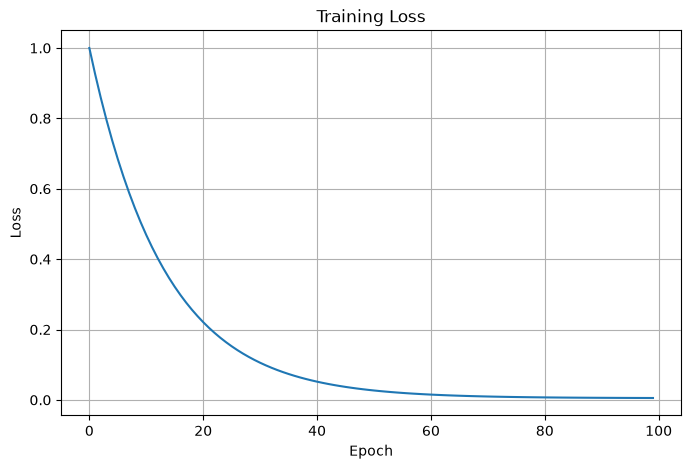

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [77]:
# Predict on the test dataset
Y_test_pred = X_test_flat @ W + b

# Convert predictions back to original scale
Y_test_pred_original = (Y_test_pred * Y_std) + Y_mean

# Convert actual values back to original scale
Y_test_actual_original = (Y_test_flat * Y_std) + Y_mean



In [81]:
# Flatten the complete testing data
y_true = Y_test_actual_original.flatten()
y_pred = Y_test_pred_original.flatten()

# Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_true - y_pred))

# Mean Squared Error (MSE)
mse = np.mean((y_true - y_pred) ** 2)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# R² Score
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

r2 = 1 - (ss_res / ss_tot)

# Pearson Correlation
correlation = np.corrcoef(y_true, y_pred)[0, 1]

# Print Results
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")
print(f"Correlation : {correlation:.4f}")

Mean Absolute Error (MAE) : 368.1015
Mean Squared Error (MSE) : 205568.6726
Root Mean Squared Error (RMSE) : 453.3968
R² Score : 0.9276
Correlation : 0.9762


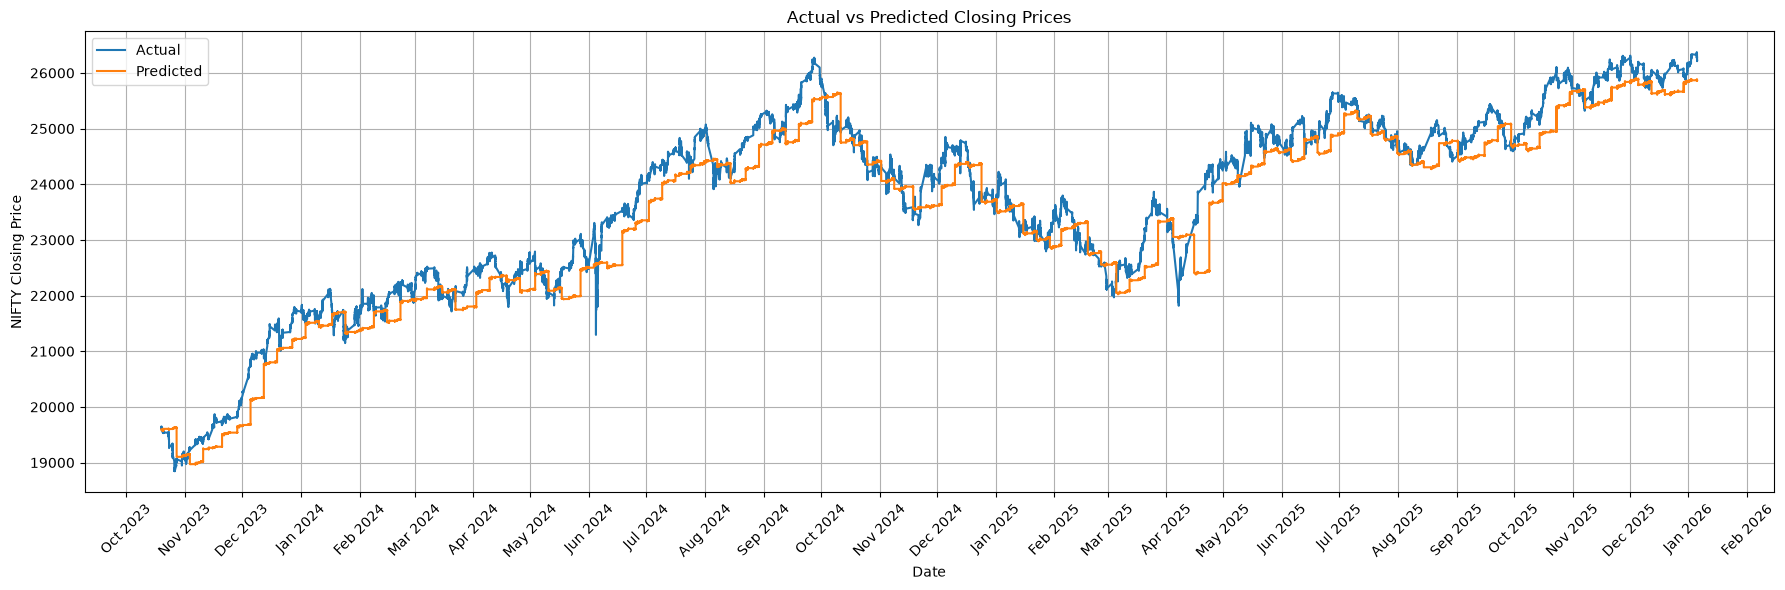

In [79]:
#Plotting the actual vs predicted graph
# Dates corresponding to every value in the test target
test_dates = []

for i in range(split_index, len(X)):
    start = i * WINDOW_SIZE

    # Dates of the target window
    target_dates = df.index[start + WINDOW_SIZE : start + (2 * WINDOW_SIZE)]

    test_dates.extend(target_dates)

test_dates = pd.to_datetime(test_dates)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(18,6))

plt.plot(test_dates,
         Y_test_actual_original.flatten(),
         label="Actual")

plt.plot(test_dates,
         Y_test_pred_original.flatten(),
         label="Predicted")

plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Date")
plt.ylabel("NIFTY Closing Price")

# Show one tick per month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

# Display month and year
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()